In [32]:

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt 
import lightgbm as lgb
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

data = pd.read_csv('supplementary_data/data.csv')
feature_columns = ["O","N","SSA","PV","RMIC","Dap","ID/IG","CD","Anion"]
target = "Cs" # 比容量


data["Anion"] = data["Anion"].replace({
    "SO4": 0,
    "OTf": 1
}).astype(int)

X = data[feature_columns]
y = data[target]

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# cs_bin = pd.qcut(y, q=10, labels=False, duplicates="drop")

cs_bin = pd.cut(y, bins=10, labels=False)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=cs_bin
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

C:\Users\luluz\AppData\Local\Temp\ipykernel_26008\2313581802.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Anion"] = data["Anion"].replace({


In [33]:
# Support Vector Regression

# Use the hyperparameter from the supplementary data
svr = SVR(
    kernel='poly',  
    degree=6,         
    coef0=3,         
    epsilon=10,      
    C=0.5           
)

svr.fit(X_train_scaled, y_train)

y_train_pred_svr = svr.predict(X_train_scaled)
y_test_pred_svr = svr.predict(X_test_scaled)

train_r2_svr = r2_score(y_train, y_train_pred_svr)
test_r2_svr = r2_score(y_test, y_test_pred_svr)
train_rmse_svr = np.sqrt(mean_squared_error(y_train, y_train_pred_svr))
test_rmse_svr = np.sqrt(mean_squared_error(y_test, y_test_pred_svr))
train_mae_svr = mean_absolute_error(y_train, y_train_pred_svr)
test_mae_svr = mean_absolute_error(y_test, y_test_pred_svr)

print("-------- SVR --------")
print(f"Train set R2 : {train_r2_svr:.4f}")
print(f"Test set R2 : {test_r2_svr:.4f}")
print(f"Train set RMSE: {train_rmse_svr:.4f}")
print(f"Test set RMSE: {test_rmse_svr:.4f}")
print(f"Train set MAE : {train_mae_svr:.4f}")
print(f"Test set MAE : {test_mae_svr:.4f}")

# cv_scores = cross_val_score(svr, X_train_scaled, y_train, cv=5, scoring='r2')
# print(f"5-Fold Cross Validation R2 : {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

-------- SVR --------
Train set R2 : 0.8627
Test set R2 : 0.7320
Train set RMSE: 14.9312
Test set RMSE: 21.1149
Train set MAE : 10.5871
Test set MAE : 14.1143


In [34]:
# Random Forest
# Use the hyperparameter from the supplementary data
rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=12,
    min_samples_leaf=1,
    min_samples_split=2,
    max_features=0.5,
    random_state=42
)
rf.fit(X_train,y_train)

y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)
train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)
train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
test_mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
print("-------- Random Forest --------")
print(f"Train set R2 : {train_r2_rf:.4f}")
print(f"Test set R2 : {test_r2_rf:.4f}")
print(f"Train set RMSE: {train_rmse_rf:.4f}")
print(f"Test set RMSE: {test_rmse_rf:.4f}")
print(f"Train set MAE : {train_mae_rf:.4f}")
print(f"Test set MAE : {test_mae_rf:.4f}")

-------- Random Forest --------
Train set R2 : 0.9871
Test set R2 : 0.9233
Train set RMSE: 4.5771
Test set RMSE: 11.2966
Train set MAE : 3.0503
Test set MAE : 7.5349


In [35]:
# LightGBM
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.18,
    max_depth=5,
    num_leaves=31,
    min_child_samples=2,
    colsample_bytree=0.3,
    reg_alpha=0.6,
    random_state=42,
    verbosity=-1
)

lgb_model.fit(X_train, y_train)

y_train_pred_lgb = lgb_model.predict(X_train)
y_test_pred_lgb = lgb_model.predict(X_test)
train_r2_lgb = r2_score(y_train,
y_train_pred_lgb)
test_r2_lgb = r2_score(y_test, y_test_pred_lgb)
train_rmse_lgb = np.sqrt(mean_squared_error(y_train, y_train_pred_lgb))
test_rmse_lgb = np.sqrt(mean_squared_error(y_test, y_test_pred_lgb))
train_mae_lgb = mean_absolute_error(y_train, y_train_pred_lgb)
test_mae_lgb = mean_absolute_error(y_test, y_test_pred_lgb)
print("-------- LightGBM --------")
print(f"Train set R2 : {train_r2_lgb:.4f}")
print(f"Test set R2 : {test_r2_lgb:.4f}")
print(f"Train set RMSE: {train_rmse_lgb:.4f}")
print(f"Test set RMSE: {test_rmse_lgb:.4f}")
print(f"Train set MAE : {train_mae_lgb:.4f}")
print(f"Test set MAE : {test_mae_lgb:.4f}")


-------- LightGBM --------
Train set R2 : 0.9989
Test set R2 : 0.9702
Train set RMSE: 1.3162
Test set RMSE: 7.0372
Train set MAE : 1.0141
Test set MAE : 4.4966


CD       18.144283
N         8.985089
SSA       7.448559
PV        6.130137
ID/IG     4.045620
Dap       3.848324
RMIC      2.591135
O         2.446050
Anion     2.122421
dtype: float64


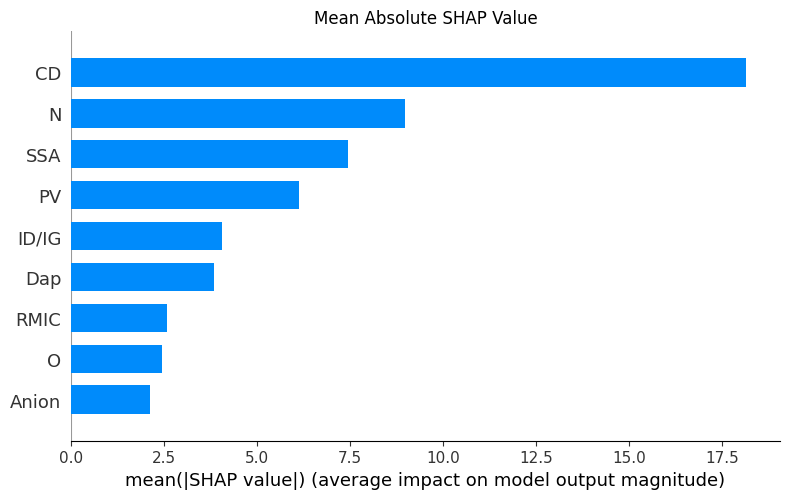

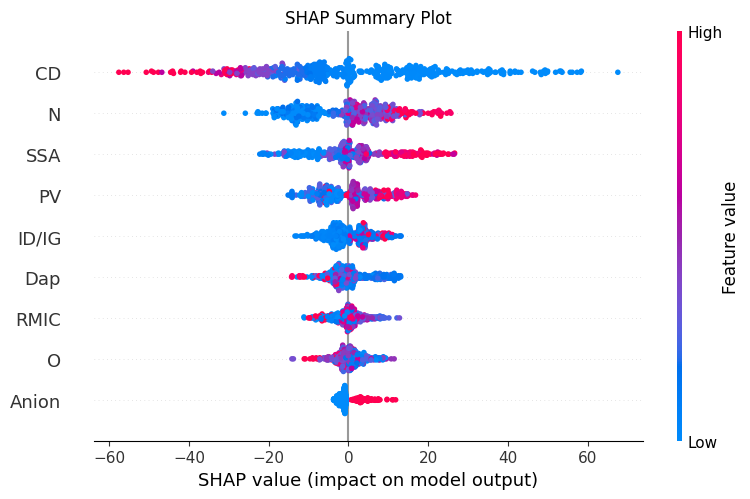

In [37]:
# Use the Train Data from LightGBM to Use SHAP
# SHAP
explainer = shap.TreeExplainer(
    lgb_model,
    feature_perturbation="tree_path_dependent"
)
shap_values = explainer.shap_values(X_train)

shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_train.columns
).sort_values(ascending=False)

print(shap_importance)

shap.summary_plot(
    shap_values,
    X_train,
    plot_type="bar",
    show=False
)
plt.title("Mean Absolute SHAP Value")
plt.tight_layout()
plt.savefig("shap_bar_mean_abs.png", dpi=300, bbox_inches='tight')  # 保存
plt.show()
plt.close()

shap.summary_plot(
    shap_values,
    X_train,
    show=False
)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.savefig("shap_summary_scatter.png", dpi=300, bbox_inches='tight')  # 保存
plt.show()
plt.close()